In [1]:
import stellarvista as sv
import pyvista as pv

## Plot all particles in tracks.h5

MultiBlock (0x7fd088280340)
  N Blocks:   10
  X Bounds:   -3.867e+02, 4.191e+02
  Y Bounds:   -3.374e+02, 2.719e+02
  Z Bounds:   -1.383e+02, 1.301e+02

PolyData (0x7fd08825d3c0)
  N Cells:    24
  N Points:   117
  N Strips:   0
  X Bounds:   3.003e+02, 4.178e+02
  Y Bounds:   2.215e+01, 1.727e+02
  Z Bounds:   -3.183e+01, 7.062e+01
  N Arrays:   8

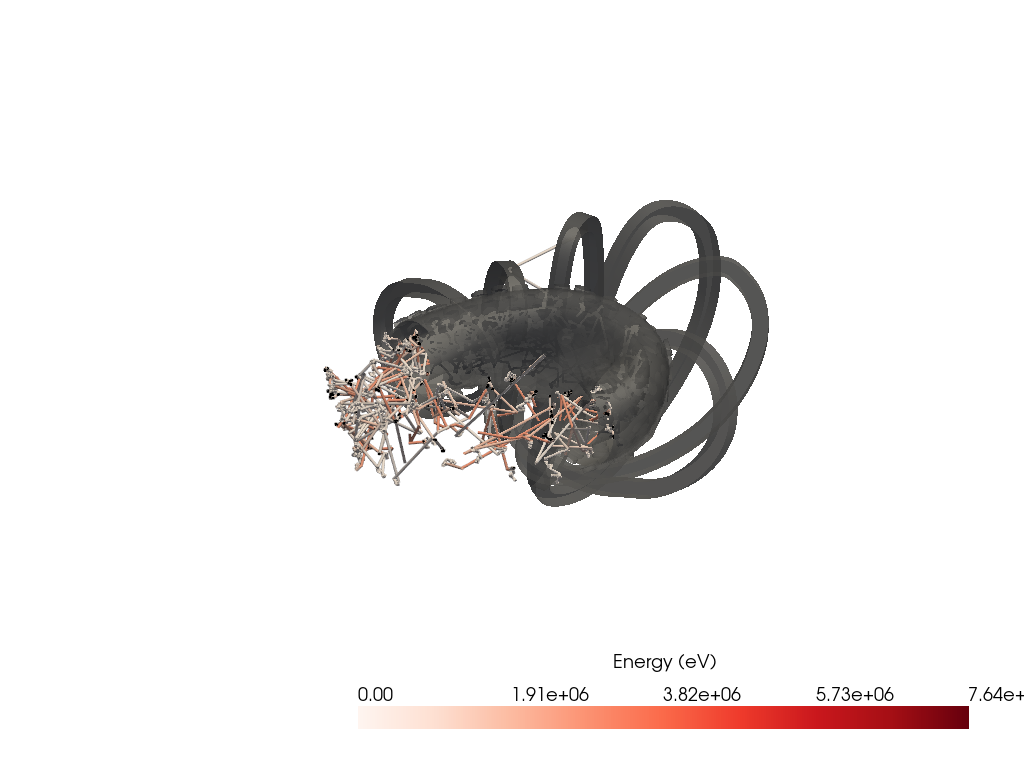

In [2]:
tracks = sv.import_particle_tracks('./model_thea/tracks.h5')

# Each particle track has been stored as a block with the track identifier set as the block name
# identifier (tuple) – Tuple of (batch, generation, particle number)
#https://docs.openmc.org/en/stable/pythonapi/generated/openmc.Track.html
display(tracks[:10])
# Each block contains the primary and secondary particle data, including
# - particle type, energy (E), weight (wgt), and more
display(tracks[0])

model = sv.import_dagmc('./model_thea/dagmc.h5m')
plot = pv.Plotter()
plot.add_mesh(model.clip('x'),
              color='gray',
              opacity=0.8,)
plot.add_mesh(tracks,
              scalars='E',
              render_lines_as_tubes=True,
              line_width=3,
              cmap='reds',
              scalar_bar_args={'title': 'Energy (eV)\n'})
plot.camera.zoom(1.25)
plot.show(jupyter_backend='static', cpos=[1,1,0.5])

## Plot by particle type

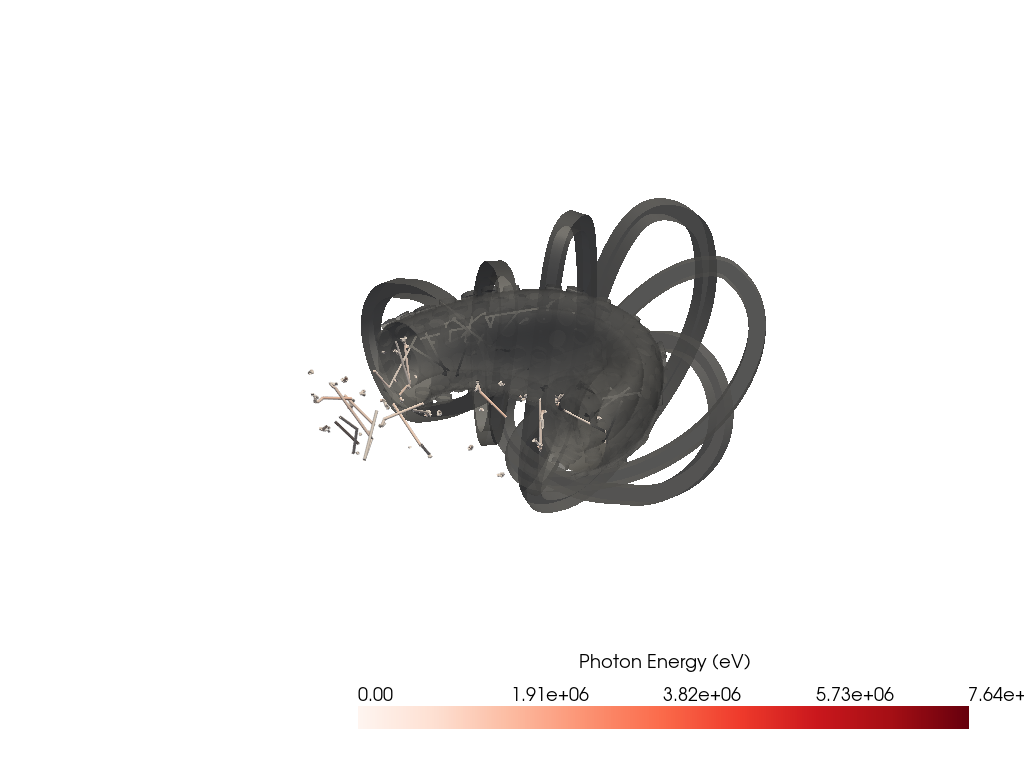

In [3]:
# particle type map: {neutron: 0, photon: 1, electron: 2, positron: 3}
for i in range(len(tracks)):
    tracks[i] = tracks[i].extract_values(1, scalars='particle_type') # extract all photon data

plot = pv.Plotter()
plot.add_mesh(model.clip('x'),
              color='gray',
              opacity=0.8,)
plot.add_mesh(tracks,
              scalars='E',
              render_lines_as_tubes=True,
              line_width=3,
              cmap='reds',
              scalar_bar_args={'title': 'Photon Energy (eV)\n'})
plot.show(jupyter_backend='static', cpos=[1,1,0.5])